In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset

df = pd.read_csv(
    r"C:\Users\91958\Desktop\Machine Learning\datasets\insurance.csv"
)

# Displaying the first five rows

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Displaying dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Statistical summary of numerical columns

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# Checking for missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1338
Columns : 7


In [7]:
# Selecting independent and dependent variables

X = df.drop("charges", axis=1)
y = df["charges"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Features:


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest



Target:


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


Features Shape: (1338, 6)
Target Shape: (1338,)


In [8]:
# Encoding categorical columns

encoder = LabelEncoder()

categorical_columns = [
    "sex",
    "smoker",
    "region"
]

for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column])

print("Encoded Features:")
display(X.head())

Encoded Features:


,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1


In [9]:
# Splitting the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (1070, 6)
Testing Features : (268, 6)
Training Labels : (1070,)
Testing Labels : (268,)


In [10]:
# Training the Gradient Boosting Regression model

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

print("Gradient Boosting Regression model trained successfully!")

Gradient Boosting Regression model trained successfully!


In [11]:
# Predicting the test data

y_pred = model.predict(X_test)

print("Predicted Insurance Charges:")
print(y_pred[:10])

Predicted Insurance Charges:
[11001.12862914  5840.17465641 28001.98011231  9745.29160234
 33639.10098055  5369.92652553  2686.29056393 15046.07464454
  4994.85131313 10957.88042886]


In [12]:
# Comparing Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,9095.06825,11001.128629
1,5272.17580,5840.174656
2,29330.98315,28001.980112
3,9301.89355,9745.291602
4,33750.29180,33639.100981
5,4536.25900,5369.926526
6,2117.33885,2686.290564
7,14210.53595,15046.074645
8,3732.62510,4994.851313
9,10264.44210,10957.880429


In [13]:
from sklearn.metrics import mean_absolute_error

# Calculating Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 2447.95


In [14]:
from sklearn.metrics import mean_squared_error

# Calculating Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 18944595.16


In [15]:
import numpy as np

# Calculating Root Mean Squared Error

rmse = np.sqrt(mse)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 4352.54


In [16]:
from sklearn.metrics import r2_score

# Calculating R² Score

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.8780


In [17]:
# Predicting insurance cost for a new customer

new_customer = pd.DataFrame({
    "age": [35],
    "sex": [1],         # Male
    "bmi": [28.5],
    "children": [2],
    "smoker": [0],      # Non-Smoker
    "region": [2]
})

predicted_charge = model.predict(new_customer)

print(f"Predicted Insurance Charge: ₹{predicted_charge[0]:,.2f}")

Predicted Insurance Charge: ₹7,598.71


In [18]:
# Displaying Gradient Boosting Hyperparameters

parameters = pd.DataFrame({
    "Hyperparameter": model.get_params().keys(),
    "Value": model.get_params().values()
})

display(parameters)

,Hyperparameter,Value
0,alpha,0.9
1,ccp_alpha,0.0
2,criterion,friedman_mse
3,init,None
4,learning_rate,0.1
5,loss,squared_error
6,max_depth,3
7,max_features,None
8,max_leaf_nodes,None
9,min_impurity_decrease,0.0


,Feature,Importance
4,smoker,0.677875
2,bmi,0.190043
0,age,0.117431
3,children,0.010485
5,region,0.003501
1,sex,0.000664


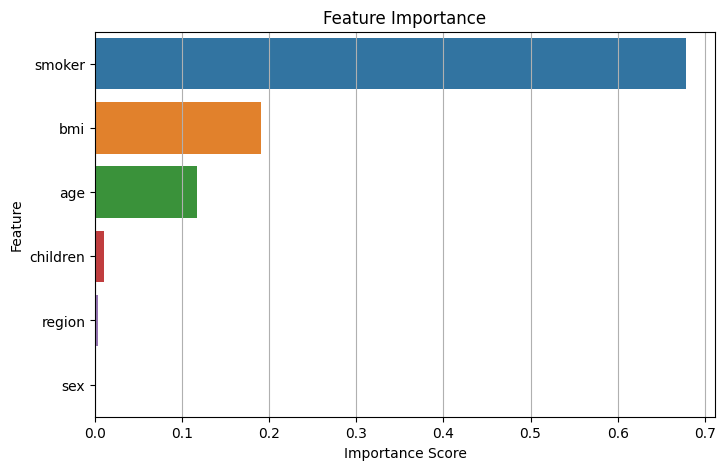

In [19]:
# Displaying Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.grid(axis="x")

plt.show()

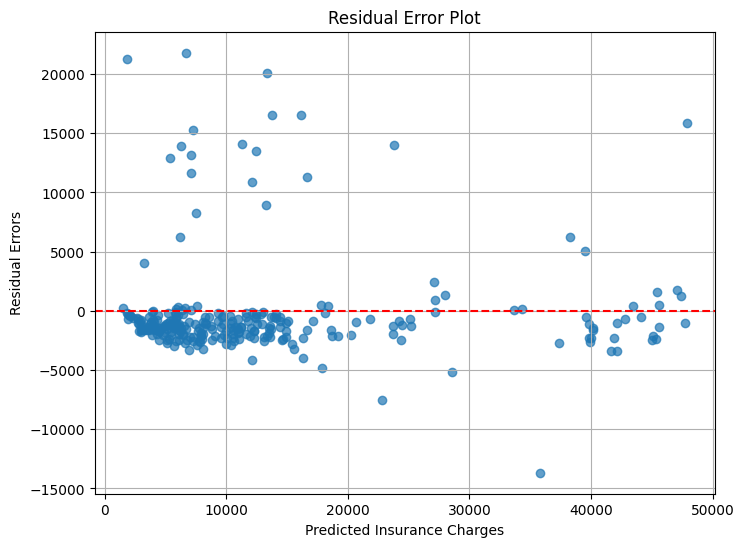

In [20]:
# Plotting Residual Errors

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Error Plot")
plt.xlabel("Predicted Insurance Charges")
plt.ylabel("Residual Errors")

plt.grid(True)

plt.show()